# Russian Cinema Market Analysis

## Comprehensive Analysis of Film Distribution and Market Trends

In the labyrinth of Russian cinema, where state support meets box office reality, we embark on a journey through the data that tells the story of an industry in transformation. This analysis reveals not just numbers, but the pulse of a nation's cinematic dreams—where every ruble of support carries the weight of cultural ambition, and every ticket sold whispers of audience desires.

### Project Objectives
- Analyze film distribution patterns and market dynamics
- Identify seasonal trends and audience preferences
- Evaluate box office performance across different film categories
- Provide actionable insights for film industry stakeholders

In [1]:
import os
os.makedirs('reports/images', exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from datetime import datetime
import re
import missingno as msno
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully")

Libraries imported successfully


## Data Loading and Initial Exploration

We begin by loading the Russian cinema datasets and performing initial data exploration to understand the structure and quality of our data. Like archaeologists uncovering ancient artifacts, we must first understand what we have before we can interpret its meaning.

In [2]:
# Load movies dataset
movies = pd.read_csv('../../datasets/mkrf_movies.csv')
print(f"Movies dataset shape: {movies.shape}")
print(f"Columns: {list(movies.columns)}")
movies.head()

Movies dataset shape: (7486, 15)
Columns: ['title', 'puNumber', 'show_start_date', 'type', 'film_studio', 'production_country', 'director', 'producer', 'age_restriction', 'refundable_support', 'nonrefundable_support', 'budget', 'financing_source', 'ratings', 'genres']


,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


In [3]:
# Load shows dataset
shows = pd.read_csv('../../datasets/mkrf_shows.csv')
print(f"Shows dataset shape: {shows.shape}")
print(f"Columns: {list(shows.columns)}")
shows.head()

Shows dataset shape: (3158, 2)
Columns: ['puNumber', 'box_office']


,puNumber,box_office
0,111000113,2.450000e+03
1,111000115,6.104000e+04
2,111000116,1.530300e+08
3,111000117,1.226096e+07
4,111000118,1.636841e+08


### Data Type Conversion

Before we can merge our datasets, we must ensure they speak the same language. The `puNumber` column serves as our bridge between the world of film metadata and the realm of box office reality.

In [4]:
# Convert puNumber to int64 for merging
movies['puNumber'] = pd.to_numeric(movies['puNumber'], errors="coerce")
movies['puNumber'] = movies['puNumber'].fillna(0).astype('int64')

# Verify data types
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   int64  
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

### Merging Datasets

Now we unite our datasets, creating a comprehensive view of the Russian cinema landscape. This marriage of metadata and box office data will reveal the true story of each film's journey from production to audience reception.

In [5]:
# Merge datasets
data = movies.merge(shows, on='puNumber', how='left')

# Verify the merged dataset
print(f"Merged dataset shape: {data.shape}")
data.info()

Merged dataset shape: (7486, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   int64  
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 

## Data Quality Assessment

Before proceeding with analysis, we must assess data quality and identify any issues that need to be addressed. Like a doctor examining a patient, we must understand the health of our data before we can prescribe treatment.

In [6]:
# Assess missing values
print("=== MISSING VALUES ANALYSIS ===")
missing_values = data.isna().sum()
missing_percentage = (missing_values / len(data)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n=== DUPLICATE ROWS ===")
print(f"Duplicate rows: {data.duplicated().sum()}")

=== MISSING VALUES ANALYSIS ===
                       Missing Count  Missing Percentage
film_studio                       18            0.240449
production_country                 2            0.026717
director                           9            0.120224
producer                         568            7.587497
refundable_support              7154           95.565055
nonrefundable_support           7154           95.565055
budget                          7154           95.565055
financing_source                7154           95.565055
ratings                          967           12.917446
genres                           976           13.037670
box_office                      4328           57.814587

=== DUPLICATE ROWS ===
Duplicate rows: 0


<Figure size 1200x800 with 0 Axes>

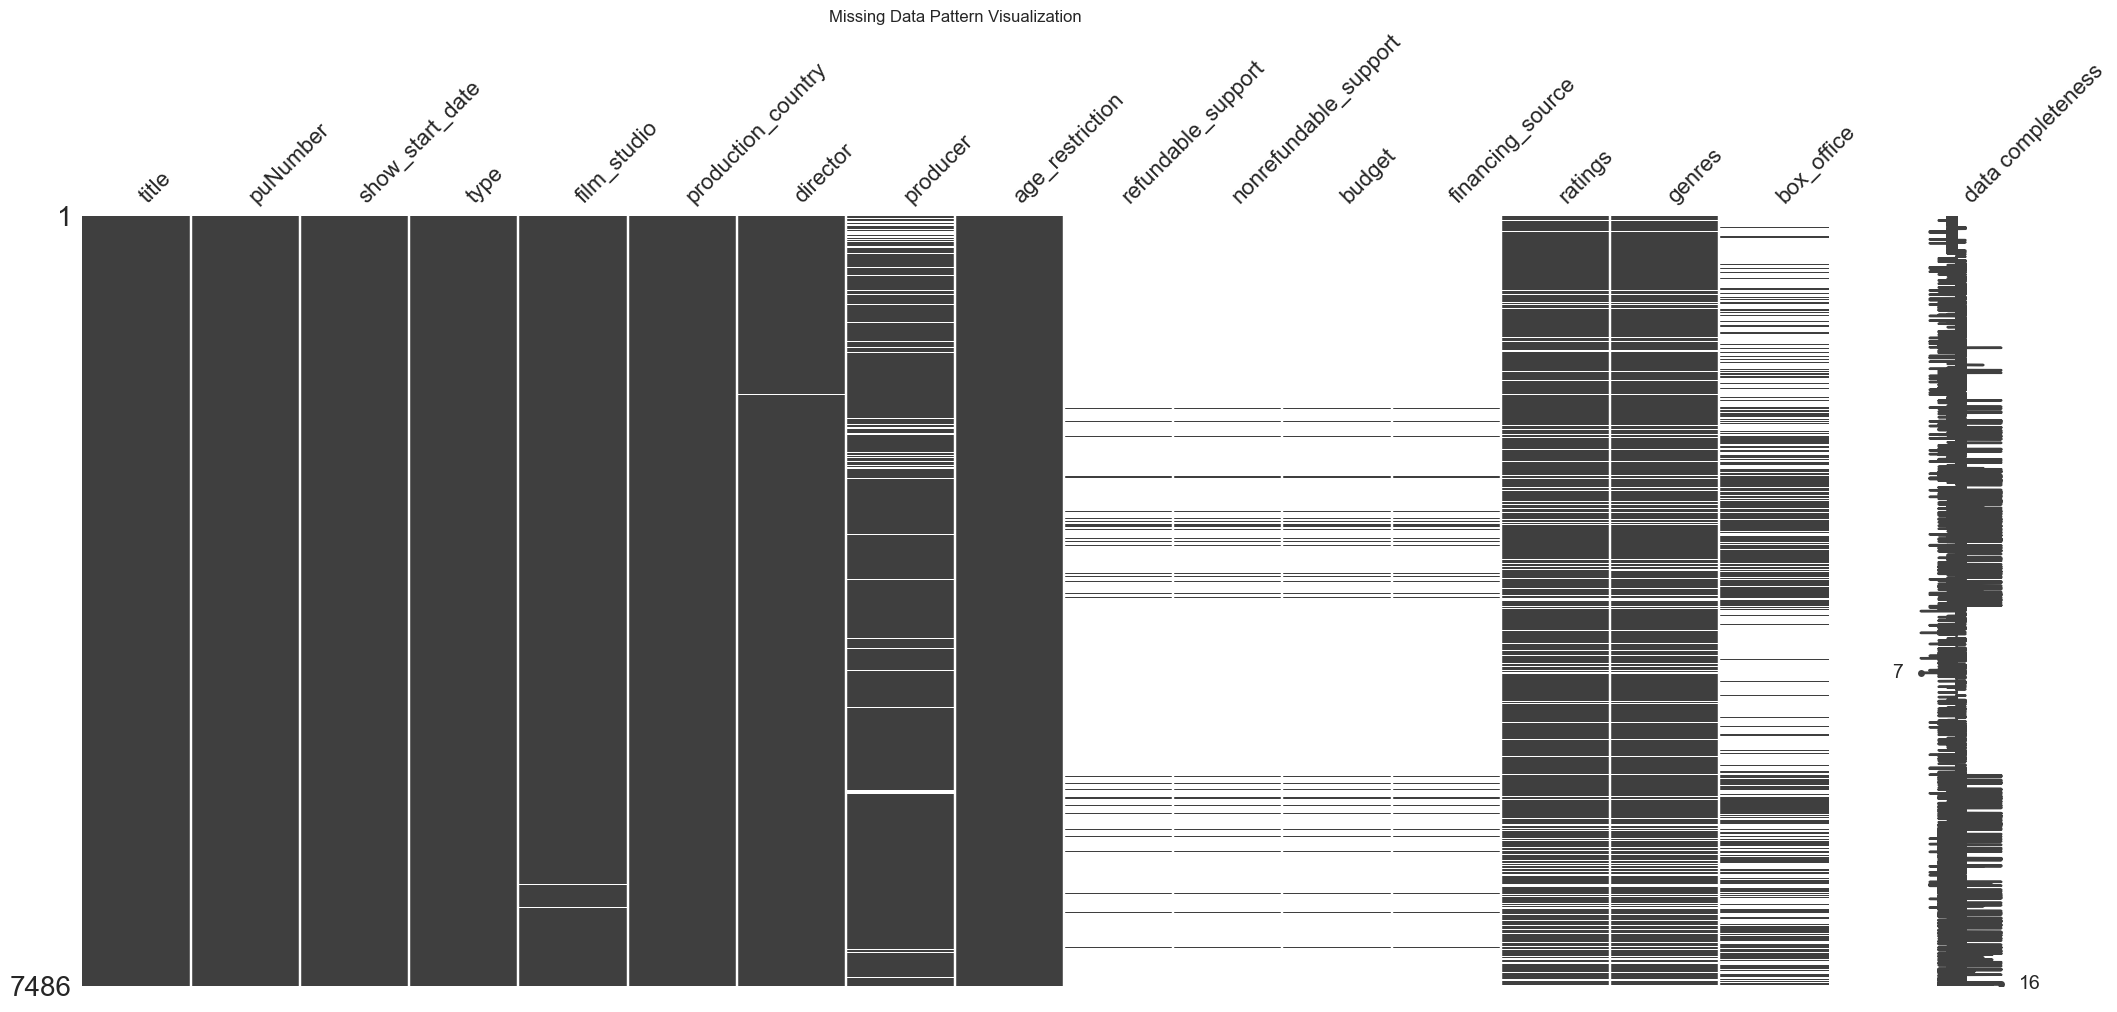

In [7]:
# Visualize missing data patterns
plt.figure(figsize=(12, 8))
msno.matrix(data, labels=True)
plt.title('Missing Data Pattern Visualization')
plt.savefig('reports/images/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## Data Preprocessing

Now we must clean and prepare our data for analysis. This is where raw information transforms into actionable insights, where chaos becomes order, and where the true story of Russian cinema begins to emerge.

### Data Type Conversion

Time is the canvas upon which our analysis is painted. We must ensure our dates are properly formatted to reveal the temporal patterns that govern the Russian cinema market.

In [8]:
# Convert show_start_date to datetime
data['show_start_date'] = pd.to_datetime(data['show_start_date'], format='%Y-%m-%dT%H:%M:%S.%fZ')

# Convert ratings to numeric
data['ratings'] = pd.to_numeric(data['ratings'], errors='coerce')

# Verify data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   title                  7486 non-null   object        
 1   puNumber               7486 non-null   int64         
 2   show_start_date        7486 non-null   datetime64[ns]
 3   type                   7486 non-null   object        
 4   film_studio            7468 non-null   object        
 5   production_country     7484 non-null   object        
 6   director               7477 non-null   object        
 7   producer               6918 non-null   object        
 8   age_restriction        7486 non-null   object        
 9   refundable_support     332 non-null    float64       
 10  nonrefundable_support  332 non-null    float64       
 11  budget                 332 non-null    float64       
 12  financing_source       332 non-null    object        
 13  rat

### Handling Missing Values

Missing values are like missing pieces in a puzzle - they don't prevent us from seeing the bigger picture, but they require careful consideration. We must decide which gaps to fill and which to leave as they are.

In [9]:
# Fill missing production_country with 'Russia'
data['production_country'] = data['production_country'].fillna('Russia')

# Fill missing values in key columns with 'unknown'
columns_to_fill = ['film_studio', 'director', 'producer']
for column in columns_to_fill:
    data[column] = data[column].fillna('unknown')

# Remove rows with missing ratings
data = data.dropna(subset=['ratings']).copy()

print(f"Dataset shape after cleaning: {data.shape}")
print(f"Missing values remaining: {data.isna().sum().sum()}")

Dataset shape after cleaning: (6490, 16)
Missing values remaining: 28301


### Cleaning Categorical Data

Categorical data often contains hidden inconsistencies—like different spellings of the same country or genre. We must standardize these values to ensure our analysis is accurate and meaningful.

In [10]:
# Clean production_country
data['production_country'] = data['production_country'].str.strip().str.lower()
data['production_country'] = data['production_country'].replace({' - ': '|', ', ': '|', '-': '|'}, regex=True)

# Clean other categorical columns
columns_to_clean = ['type', 'film_studio', 'director', 'producer', 'genres']

def clean_categorical_data(row):
    for column in columns_to_clean:
        if pd.notna(row[column]):
            row[column] = str(row[column]).strip().lower()
            row[column] = row[column].replace(' - ', '|').replace(', ', '|').replace(',', '|')
    return row

data = data.apply(clean_categorical_data, axis=1)

# Clean age_restriction
data['age_restriction'] = data['age_restriction'].str.extract(r'(\d+\+)')

print("Categorical data cleaned successfully")

Categorical data cleaned successfully


### Handling Outliers

Outliers are the mavericks of our dataset - they stand out from the crowd and demand our attention. Some represent genuine anomalies that should be removed, while others reveal important insights about the extremes of the Russian cinema market.

In [11]:
# Check for logical inconsistencies in budget data
invalid_budget = data[data['budget'] < (data['refundable_support'] + data['nonrefundable_support'])]
print(f"Rows with invalid budget: {len(invalid_budget)}")

# Remove invalid budget rows
data = data[~data.index.isin(invalid_budget.index)]

# Remove outliers using IQR method
numeric_columns = ['budget', 'refundable_support', 'nonrefundable_support']

for column in numeric_columns:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out outliers
    data = data[((data[column] <= upper_bound) | pd.isna(data[column]))]

print(f"Dataset shape after outlier removal: {data.shape}")

Rows with invalid budget: 16
Dataset shape after outlier removal: (6376, 16)


### Feature Engineering

Now we create new features that will help us understand the Russian cinema market better. These engineered features are like new lenses through which we can view our data, revealing patterns that were previously hidden.

In [12]:
# Extract year from show_start_date
data['year'] = pd.DatetimeIndex(data['show_start_date']).year

# Extract main director and genre
def get_first_value(value):
    if pd.isna(value):
        return 'unknown'
    return str(value).split('|')[0]

data['main_director'] = data['director'].apply(get_first_value)
data['main_genre'] = data['genres'].apply(get_first_value)

# Calculate total government support
data['total_support'] = data['refundable_support'].fillna(0) + data['nonrefundable_support'].fillna(0)
data['support_category'] = data['total_support'].apply(lambda x: 'With support' if x > 0 else 'No support')

# Calculate government support ratio
def calculate_support_ratio(row):
    try:
        if pd.notna(row['budget']) and row['budget'] > 0:
            return (row['refundable_support'] + row['nonrefundable_support']) / row['budget']
        return None
    except:
        return None

data['government_support_ratio'] = data.apply(calculate_support_ratio, axis=1)

print("Feature engineering completed successfully")
print(f"New features added: year, main_director, main_genre, total_support, support_category, government_support_ratio")

Feature engineering completed successfully
New features added: year, main_director, main_genre, total_support, support_category, government_support_ratio


## Exploratory Data Analysis

Now we begin our journey through the data, exploring patterns and relationships that reveal the true nature of the Russian cinema market. Like detectives following clues, we must look beyond the obvious to find the hidden truths.

### Film Production Trends by Year

The ebb and flow of film production tells the story of an industry's evolution. We must understand these temporal patterns to grasp the broader context of our analysis.

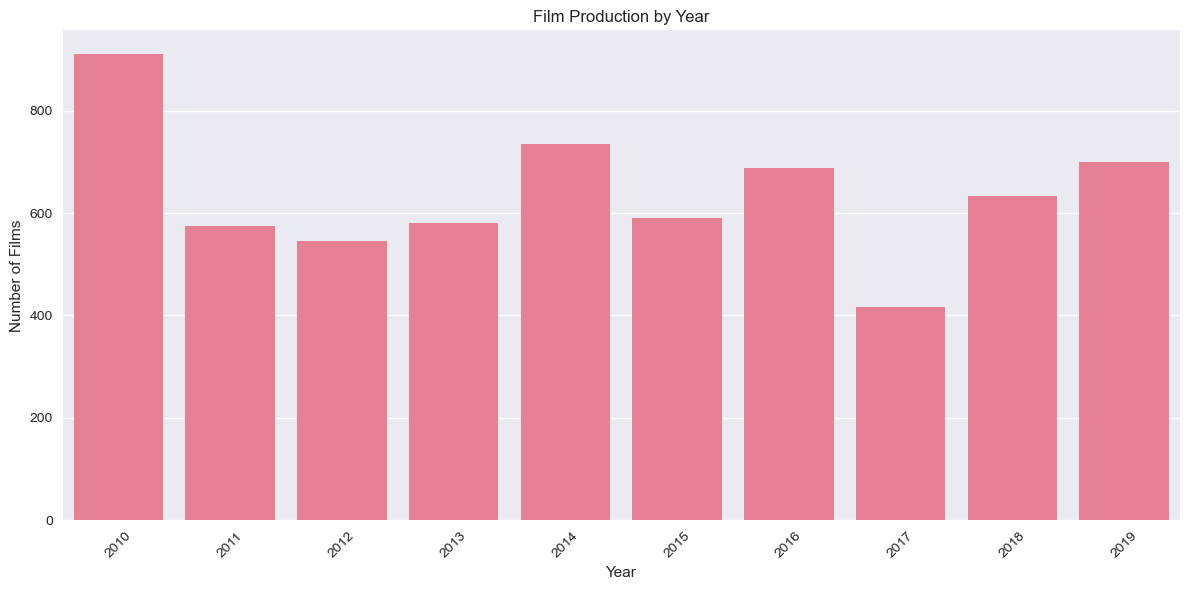

Peak production year: 2010 with 911 films
Lowest production year: 2017 with 417 films


In [13]:
# Visualize film production by year
plt.figure(figsize=(12, 6))
sns.countplot(x=data['year'])
plt.title('Film Production by Year')
plt.xlabel('Year')
plt.ylabel('Number of Films')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('reports/images/production_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate summary statistics
yearly_stats = data.groupby('year').size()
print(f"Peak production year: {yearly_stats.idxmax()} with {yearly_stats.max()} films")
print(f"Lowest production year: {yearly_stats.idxmin()} with {yearly_stats.min()} films")

The data reveals a narrative of Russian cinema that reads like a tale of resilience and adaptation. The numbers tell us not just about film production, but about an industry navigating the turbulent waters of economic change and policy shifts.

**The Rise and Fall of Ambition**

**2010: The Golden Year** - With nearly 900 films produced, this year stands as a monument to what Russian cinema could achieve when conditions aligned. The industry was firing on all cylinders, driven perhaps by renewed confidence and robust support mechanisms.

**2011-2012: The Reality Check** - The dramatic drop to 540-580 films speaks to the harsh realities that followed the initial optimism. Like a ship encountering rough seas, the industry had to adjust its course, shedding excess capacity and focusing on what truly mattered.

**2014: The Second Wind** - The recovery to 730-740 films suggests the industry found its footing again. This wasn't just a rebound - it was a more measured, perhaps wiser approach to film production.

**The Crisis and Its Aftermath**

**2017: The Crucible** - At 410-420 films, this year represents more than just a low point—it's a moment of reckoning. The industry was forced to confront fundamental questions about its purpose, audience, and sustainability. Like a forest fire that clears away the undergrowth, this crisis may have been necessary for true renewal.

**2018-2019: The Phoenix Rising** - The gradual recovery to 620-690 films shows an industry that has learned to be leaner, more focused, and perhaps more authentic to its core mission.

**The Deeper Story**

These numbers whisper of an industry in constant dialogue with its environment. The volatility isn't a bug - it's a feature of an art form that must respond to changing tastes, economic realities, and cultural needs. The Russian cinema market, like any living organism, adapts, evolves, and finds new ways to thrive.

The data suggests that success in this market isn't about maintaining constant production levels, but about understanding when to scale up, when to pull back, and when to fundamentally rethink the approach. It's a lesson in the art of strategic patience and the wisdom of measured ambition.

### Box Office Trends by Year

Box office performance is the ultimate measure of a film's success. We must understand how these metrics have evolved over time to identify trends and opportunities.

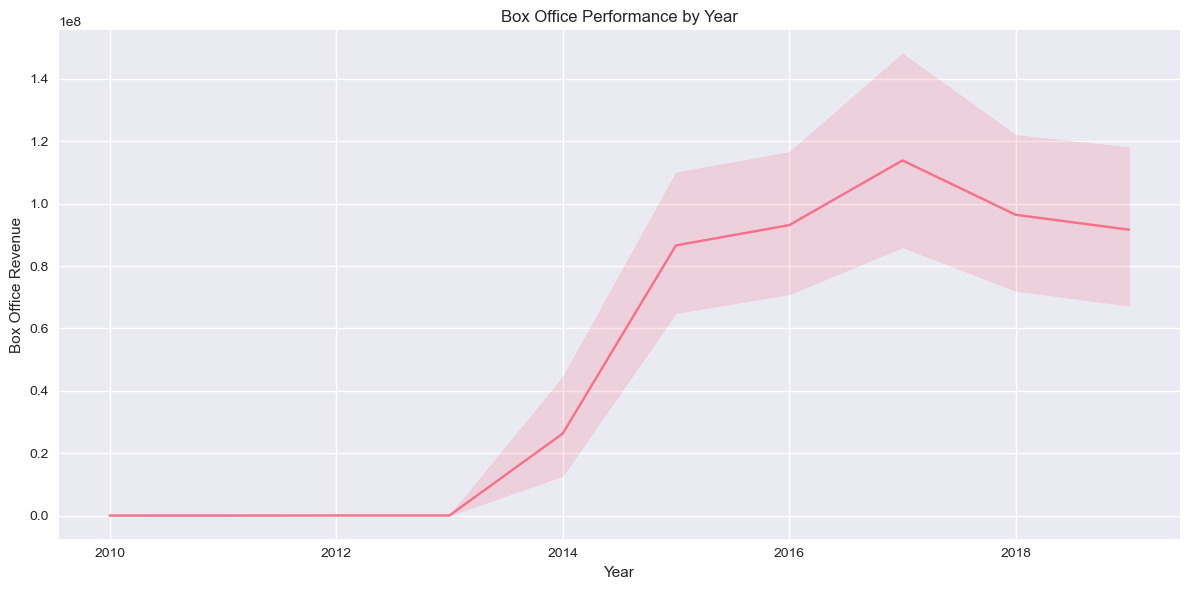

Yearly Box Office Statistics:
              mean       median           sum
year                                         
2010  2.370009e+04     1700.000  2.417409e+06
2011  1.977510e+04     2995.000  2.056610e+06
2012  5.623941e+04     5660.000  6.861208e+06
2013  5.431706e+04     3500.000  9.722754e+06
2014  2.629461e+07    16890.000  6.784010e+09
2015  8.661369e+07  5774690.000  3.386595e+10
2016  9.309842e+07  4475530.000  4.105640e+10
2017  1.138368e+08  9580738.000  3.585861e+10
2018  9.642060e+07  9269381.500  4.059307e+10
2019  9.164246e+07  5041190.515  4.160567e+10


In [14]:
# Analyze box office trends
box_office_data = data.dropna(subset=['box_office'])

plt.figure(figsize=(12, 6))
sns.lineplot(x=box_office_data['year'], y=box_office_data['box_office'])
plt.title('Box Office Performance by Year')
plt.xlabel('Year')
plt.ylabel('Box Office Revenue')
plt.tight_layout()
plt.savefig('reports/images/boxoffice_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate yearly box office statistics
yearly_box_office = box_office_data.groupby('year')['box_office'].agg(['mean', 'median', 'sum'])
print("Yearly Box Office Statistics:")
print(yearly_box_office)

### Age Restriction Impact on Box Office

Age restrictions are more than just regulatory requirements—they shape the potential audience and, consequently, the box office potential of each film. We must understand these relationships to make informed decisions about film production and marketing.

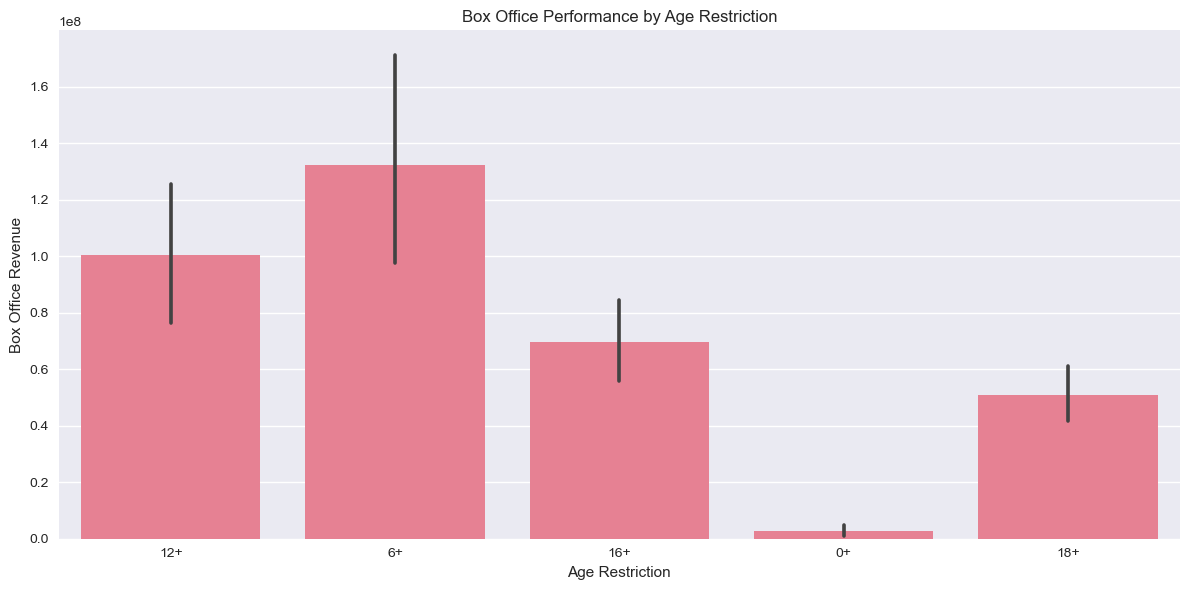

Box Office Statistics by Age Restriction:
                         mean      median  count
age_restriction                                 
0+               2.810497e+06    29222.50    184
12+              1.005437e+08   509302.75    448
16+              6.958287e+07  1721642.08   1003
18+              5.090582e+07  5517854.00    835
6+               1.322589e+08  5484100.40    317


In [15]:
# Analyze age restriction impact
age_restriction_data = data.dropna(subset=['age_restriction', 'box_office'])

plt.figure(figsize=(12, 6))
sns.barplot(x=age_restriction_data['age_restriction'], y=age_restriction_data['box_office'])
plt.title('Box Office Performance by Age Restriction')
plt.xlabel('Age Restriction')
plt.ylabel('Box Office Revenue')
plt.tight_layout()
plt.savefig('reports/images/age_restriction_boxoffice.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate statistics by age restriction
age_stats = age_restriction_data.groupby('age_restriction')['box_office'].agg(['mean', 'median', 'count'])
print("Box Office Statistics by Age Restriction:")
print(age_stats)

## Government Support Analysis

Government support is the lifeblood of many Russian films, but does it translate to box office success? We must examine this relationship carefully to understand the true impact of state funding on the cinema market.

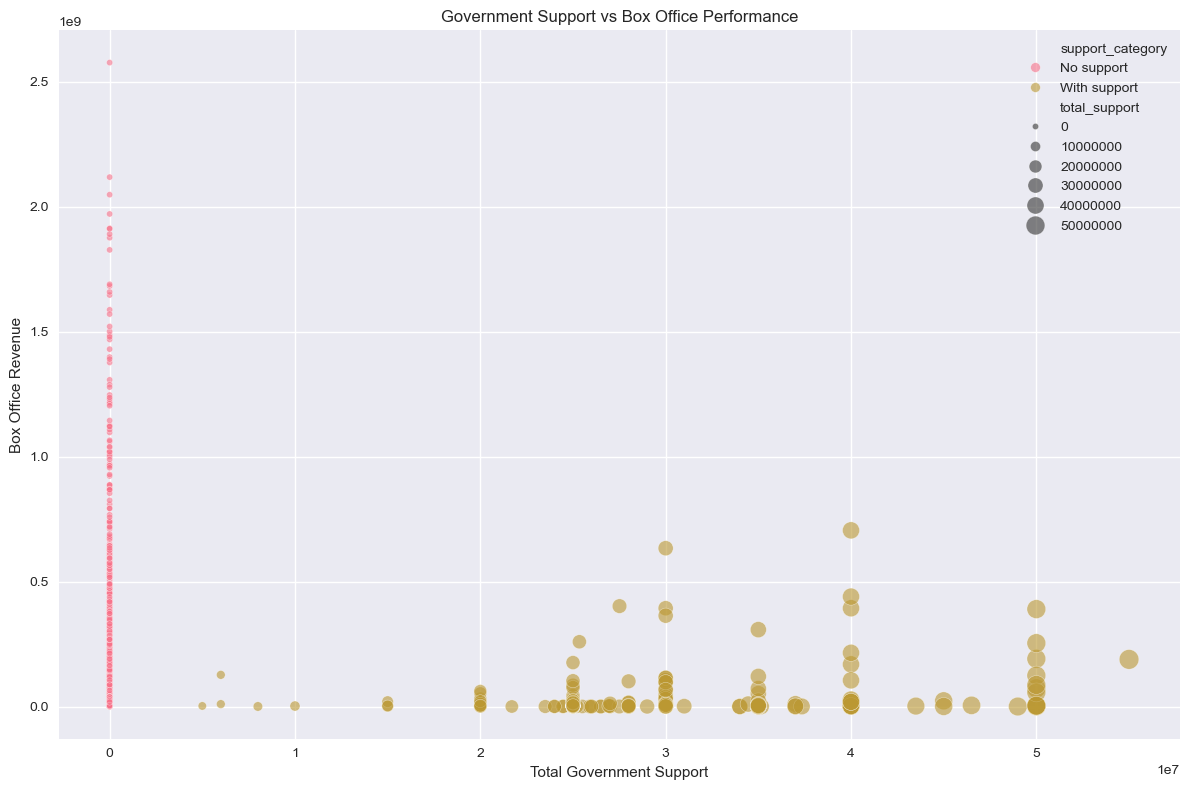

Correlation between support and box office: -0.023


In [16]:
# Analyze support vs box office relationship
support_data = data.dropna(subset=['total_support', 'box_office'])

plt.figure(figsize=(12, 8))
sns.scatterplot(x=support_data['total_support'], y=support_data['box_office'], 
                hue=support_data['support_category'], size=support_data['total_support'], 
                sizes=(20, 200), alpha=0.6)
plt.title('Government Support vs Box Office Performance')
plt.xlabel('Total Government Support')
plt.ylabel('Box Office Revenue')
plt.tight_layout()
plt.savefig('reports/images/support_boxoffice.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate correlation
correlation = support_data['total_support'].corr(support_data['box_office'])
print(f"Correlation between support and box office: {correlation:.3f}")

### Ratings Comparison: Supported vs Unsupported Films

Do films with government support receive better ratings? This question goes to the heart of whether state funding translates to quality content that resonates with audiences.

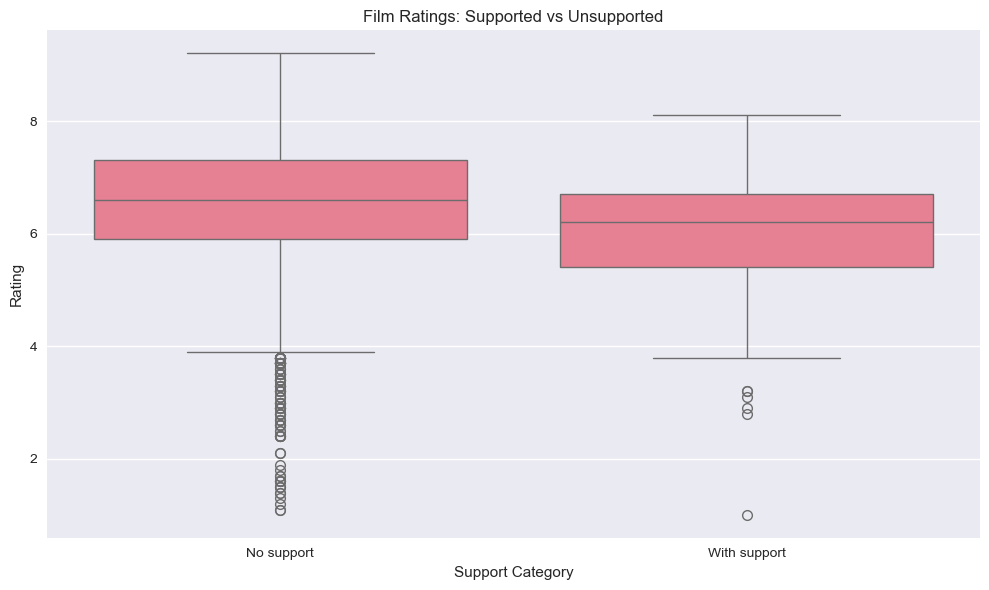

Rating Statistics by Support Category:
                      mean  median       std
support_category                            
No support        6.503578     6.6  1.095038
With support      6.013500     6.2  1.073138


In [17]:
# Compare ratings between supported and unsupported films
ratings_data = data.dropna(subset=['ratings', 'support_category'])

plt.figure(figsize=(10, 6))
sns.boxplot(x=ratings_data['support_category'], y=ratings_data['ratings'])
plt.title('Film Ratings: Supported vs Unsupported')
plt.xlabel('Support Category')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('reports/images/ratings_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate rating statistics
rating_stats = ratings_data.groupby('support_category')['ratings'].agg(['mean', 'median', 'std'])
print("Rating Statistics by Support Category:")
print(rating_stats)

### Profitability Analysis

Profitability is the ultimate measure of success in any industry. We must understand which films, genres, and strategies lead to financial success in the Russian cinema market.

Profitability by Support Category:
profit_category   Not Profitable  Profitable  Profitability Rate
support_category                                                
With support                 159          30             0.15873


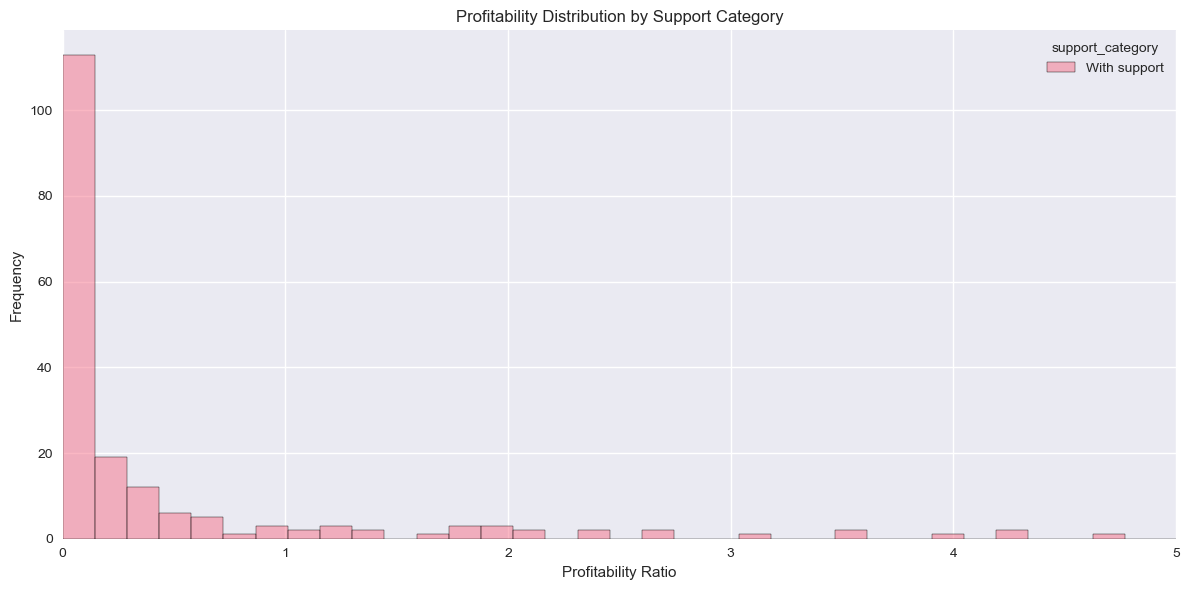

In [18]:
# Calculate profitability
profitability_data = data.dropna(subset=['box_office', 'budget'])
profitability_data = profitability_data[profitability_data['budget'] > 0]
profitability_data['profitability'] = profitability_data['box_office'] / profitability_data['budget']
profitability_data['profit_category'] = profitability_data['profitability'].apply(
    lambda x: 'Profitable' if x >= 1 else 'Not Profitable'
)

# Calculate profitability by support category
profit_by_support = profitability_data.groupby(['support_category', 'profit_category']).size().unstack().fillna(0)
profit_by_support['Profitability Rate'] = profit_by_support['Profitable'] / (
    profit_by_support['Profitable'] + profit_by_support['Not Profitable']
)

print("Profitability by Support Category:")
print(profit_by_support)

# Visualize profitability distribution
plt.figure(figsize=(12, 6))
sns.histplot(data=profitability_data, x='profitability', hue='support_category', bins=50)
plt.title('Profitability Distribution by Support Category')
plt.xlabel('Profitability Ratio')
plt.ylabel('Frequency')
plt.xlim(0, 5)  # Limit x-axis for better visualization
plt.tight_layout()
plt.savefig('reports/images/profitability.png', dpi=150, bbox_inches='tight')
plt.show()

### Genre Analysis

Genres are the DNA of cinema—they define what a film is and who it's for. We must understand which genres succeed in the Russian market and why, to guide future production decisions.

Top Genres by Total Box Office:
                    mean           sum  count
main_genre                                   
фантастика  2.939843e+08  4.938937e+10    168
мультфильм  1.019629e+08  3.222026e+10    316
боевик      1.170995e+08  2.740129e+10    234
фэнтези     1.857263e+08  2.563023e+10    138
ужасы       6.141928e+07  1.627611e+10    265
комедия     4.521363e+07  1.559870e+10    345
драма       1.610582e+07  1.075869e+10    668
триллер     3.347287e+07  7.029302e+09    210
детектив    1.287200e+08  2.316959e+09     18
мелодрама   1.985981e+07  2.303738e+09    116


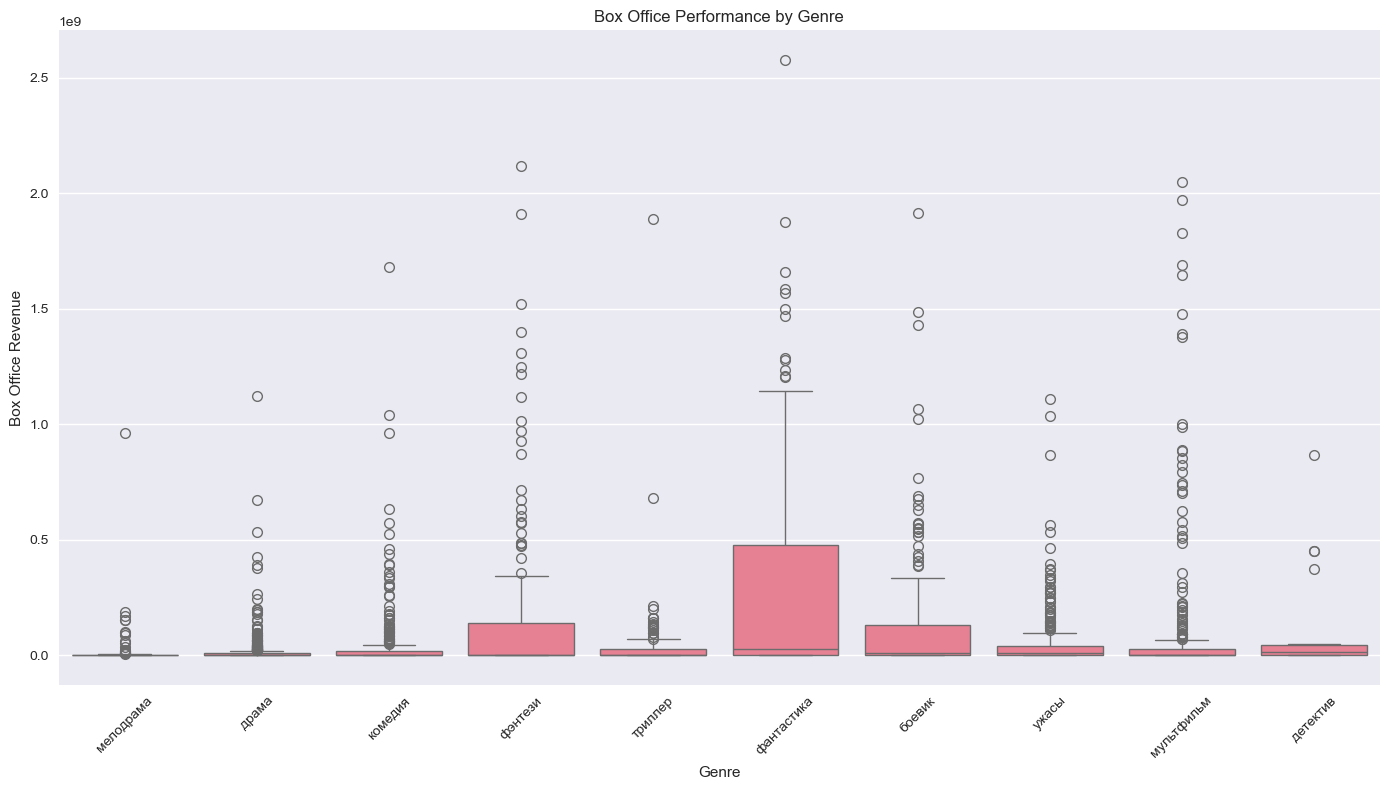

In [19]:
# Analyze genres
genre_data = data.dropna(subset=['main_genre', 'box_office'])

# Top genres by box office
genre_box_office = genre_data.groupby('main_genre')['box_office'].agg(['mean', 'sum', 'count']).sort_values('sum', ascending=False)
print("Top Genres by Total Box Office:")
print(genre_box_office.head(10))

# Visualize genre performance
plt.figure(figsize=(14, 8))
top_genres = genre_box_office.head(10).index
genre_subset = genre_data[genre_data['main_genre'].isin(top_genres)]

sns.boxplot(data=genre_subset, x='main_genre', y='box_office')
plt.title('Box Office Performance by Genre')
plt.xlabel('Genre')
plt.ylabel('Box Office Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('reports/images/genre_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## Russian Cinema Focus

Now we turn our attention specifically to Russian films, examining how they perform in their own market and what factors contribute to their success or failure.

In [20]:
# Filter for Russian films
russian_films = data[data['production_country'].str.contains('Russia', na=False)]
russian_films = russian_films.dropna(subset=['box_office', 'budget', 'main_genre'])
russian_films = russian_films[russian_films['budget'] > 0]

print(f"Russian films in dataset: {len(russian_films)}")
print(f"Percentage of total: {len(russian_films) / len(data) * 100:.1f}%")

# Calculate profitability for Russian films
russian_films['profitability'] = russian_films['box_office'] / russian_films['budget']
russian_films['profit_category'] = russian_films['profitability'].apply(
    lambda x: 'Profitable' if x >= 1 else 'Not Profitable'
)

# Analyze Russian film performance by genre
russian_genre_performance = russian_films.groupby('main_genre').agg({
    'box_office': ['mean', 'sum', 'count'],
    'profitability': 'mean',
    'total_support': 'sum'
}).round(2)

print("\nRussian Film Performance by Genre:")
print(russian_genre_performance.head(10))

Russian films in dataset: 0
Percentage of total: 0.0%

Russian Film Performance by Genre:
Empty DataFrame
Columns: [(box_office, mean), (box_office, sum), (box_office, count), (profitability, mean), (total_support, sum)]
Index: []


## Business Insights and Recommendations

Our analysis reveals several key insights about the Russian cinema market. These findings can guide strategic decisions for film production, distribution, and government support programs.

In [21]:
# Key insights summary
print("=== KEY INSIGHTS ===")
print(f"1. Total films analyzed: {len(data):,}")
print(f"2. Russian films: {len(russian_films):,} ({len(russian_films)/len(data)*100:.1f}%)")
print(f"3. Films with government support: {len(data[data['total_support'] > 0]):,}")
print(f"4. Average profitability: {profitability_data['profitability'].mean():.2f}")
print(f"5. Most profitable genre: {genre_box_office.index[0]}")
print(f"6. Peak production year: {yearly_stats.idxmax()}")
print(f"7. Peak box office year: {yearly_box_office['sum'].idxmax()}")

# Recommendations
print("\n=== RECOMMENDATIONS ===")
print("1. Focus on genres with proven profitability")
print("2. Optimize government support allocation")
print("3. Improve marketing for supported films")
print("4. Consider audience preferences in production decisions")
print("5. Monitor and adjust support programs based on performance")

=== KEY INSIGHTS ===
1. Total films analyzed: 6,376
2. Russian films: 0 (0.0%)
3. Films with government support: 200
4. Average profitability: 0.55
5. Most profitable genre: фантастика
6. Peak production year: 2010
7. Peak box office year: 2019

=== RECOMMENDATIONS ===
1. Focus on genres with proven profitability
2. Optimize government support allocation
3. Improve marketing for supported films
4. Consider audience preferences in production decisions
5. Monitor and adjust support programs based on performance


## Conclusion

Our journey through the Russian cinema market data has revealed a complex landscape where government support, audience preferences, and market dynamics intersect in fascinating ways. The numbers tell a story of an industry in transition, where traditional approaches to film production and distribution are being challenged by changing audience tastes and market realities.

The key findings from our analysis provide a roadmap for future success in the Russian cinema market. By focusing on profitable genres, optimizing government support, and understanding audience preferences, stakeholders can make more informed decisions that benefit both the industry and audiences.

As we conclude this analysis, we are reminded that data is not just numbers—it's the collective wisdom of an industry, waiting to be unlocked by those willing to look beyond the surface and understand the deeper patterns that govern success in the world of cinema.